# Embedding model bake-off: OpenRouter + Modal-hosted models vs. local baseline

Evaluates 12 embedding sources against the corpus's current local embedding: 7 hosted
via OpenRouter (`qwen/qwen3-embedding-8b`, `openai/text-embedding-3-large`,
`baai/bge-m3`, `mistralai/mistral-embed-2312`, `google/gemini-embedding-2`,
`nvidia/nemotron-3-embed-1b:free`, `perplexity/pplx-embed-v1-4b`) and 4 run on GPU via
Modal (`allenai/specter2`, `Kingsoft-LLM/QZhou-Embedding`,
`infgrad/Jasper-Token-Compression-600M`, `Qwen/Qwen3-Embedding-4B` -- see
`scripts/modal_embeddings.py`). Same `StratifiedGroupKFold` fold design and held-out
use case as `notebooks/experiments/wf_fold_pca_test.ipynb`. Feature/embedding evaluation
only -- does not build the downstream stacked classifier.

In [1]:
from pathlib import Path
import re
import sys
import time
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, fbeta_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

sys.path.insert(0, "../../scripts")
from embedding_utils import MODAL_MODELS, MODEL_CONFIGS, OPENROUTER_MODELS, embed_papers, embed_texts
from latent_space_utils import centroid_analysis, dispersion_metrics

load_dotenv(Path("../../.env"))

DATA_PATH = Path("../../data/processed/papers_combined.parquet")
CACHE_DIR = Path("../../data/processed/embeddings_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
HOLDOUT_USE_CASE = "tech_forecasting"  # same choice as wf_fold_pca_test.ipynb
N_SPLITS = 5
RANDOM_STATE = 42
REMOTE_MODELS = OPENROUTER_MODELS + MODAL_MODELS  # need an API/GPU call, unlike LOCAL_MODEL
MODEL_SOURCES = [LOCAL_MODEL] + REMOTE_MODELS

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

df = pd.read_parquet(DATA_PATH)
assert df["embed_model"].str.split("@").str[0].nunique() == 1, "expected one local embed_model across the export"
print(f"Loaded {len(df)} rows x {len(df.columns)} columns")
print(f"Comparing {len(MODEL_SOURCES)} embedding sources: {MODEL_SOURCES}")

Loaded 2873 rows x 50 columns
Comparing 12 embedding sources: ['sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'qwen/qwen3-embedding-8b', 'openai/text-embedding-3-large', 'baai/bge-m3', 'mistralai/mistral-embed-2312', 'google/gemini-embedding-2', 'nvidia/nemotron-3-embed-1b:free', 'perplexity/pplx-embed-v1-4b', 'allenai/specter2', 'Kingsoft-LLM/QZhou-Embedding', 'infgrad/Jasper-Token-Compression-600M', 'Qwen/Qwen3-Embedding-4B']


## A. Data + fold design (reused from wf_fold_pca_test.ipynb)

In [2]:
labelled = df[df["triage_label"].isin(["positive", "negative"])].copy()
labelled["y"] = (labelled["triage_label"] == "positive").astype(int)

dev_pool = labelled[labelled["use_case_key"] != HOLDOUT_USE_CASE].reset_index(drop=True).copy()
holdout = labelled[labelled["use_case_key"] == HOLDOUT_USE_CASE].reset_index(drop=True).copy()
print(f"Dev pool: {len(dev_pool)} rows across {dev_pool['use_case_key'].nunique()} use cases")
print(dev_pool.groupby(["use_case_key", "triage_label"], observed=True).size())
print(f"\nHoldout ({HOLDOUT_USE_CASE}): {len(holdout)} rows")
print(holdout["triage_label"].value_counts())

Dev pool: 1588 rows across 5 use cases
use_case_key     triage_label
carbon_capture   positive        147
                 negative        150
cement_binders   positive        170
                 negative         92
ner              positive        223
                 negative         89
soil_microbiome  positive         94
                 negative        263
solar_leo        positive        276
                 negative         84
dtype: int64

Holdout (tech_forecasting): 264 rows
triage_label
positive    157
negative    107
pass          0
Name: count, dtype: int64


In [3]:
def first_author(s):
    if pd.isna(s) or s.strip() == "":
        return None
    return re.sub(r"\s+", " ", s.split(",")[0].strip())

dev_pool["first_author"] = dev_pool["authors"].apply(first_author)
dev_pool["group_key"] = dev_pool["first_author"].fillna(dev_pool["paper_id"])
dev_pool["strat_key"] = dev_pool["use_case_key"] + "__" + dev_pool["triage_label"].astype(str)

X_idx = np.arange(len(dev_pool))
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
FOLDS = list(sgkf.split(X_idx, dev_pool["strat_key"].to_numpy(), dev_pool["group_key"].to_numpy()))

fold_assignment = np.full(len(dev_pool), -1)
for fold_i, (_, test_idx) in enumerate(FOLDS):
    fold_assignment[test_idx] = fold_i
dev_pool["fold"] = fold_assignment

groups_per_fold = dev_pool.groupby("fold")["group_key"].apply(set)
violations = sum(len(groups_per_fold[i] & groups_per_fold[j])
                  for i in range(N_SPLITS) for j in range(i + 1, N_SPLITS))
print(f"Fold check -- cross-fold group_key overlaps: {violations} (0 expected by construction)")
print(pd.crosstab([dev_pool["use_case_key"], dev_pool["triage_label"]], dev_pool["fold"]))

y_dev = dev_pool["y"].to_numpy()
y_holdout = holdout["y"].to_numpy()
dev_use_case_keys = dev_pool["use_case_key"].to_numpy()
holdout_use_case_keys = holdout["use_case_key"].to_numpy()

Fold check -- cross-fold group_key overlaps: 0 (0 expected by construction)
fold                           0   1   2   3   4
use_case_key    triage_label                    
carbon_capture  positive      30  30  29  29  29
                negative      30  30  30  30  30
cement_binders  positive      34  34  34  34  34
                negative      18  18  19  19  18
ner             positive      45  45  44  45  44
                negative      18  17  18  18  18
soil_microbiome positive      18  19  19  19  19
                negative      53  52  53  52  53
solar_leo       positive      55  56  55  55  55
                negative      16  17  17  17  17


## B. Text to embed

In [4]:
all_labelled = pd.concat([dev_pool, holdout], ignore_index=True)
n_dev = len(dev_pool)
titles = all_labelled["title"].fillna("").tolist()
abstracts = all_labelled["abstract"].fillna("").tolist()
paper_ids = all_labelled["paper_id"].tolist()

# Papers: title + abstract (embed_papers handles the join/prefix per model, see embedding_utils.py).
# Use case query text: use_case_name + problem_statement + objective + domain_industry +
# domain_application, concatenated -- these are broadcast per use_case_key onto every row.
USE_CASE_COLS = ["use_case_name", "problem_statement", "objective", "domain_industry", "domain_application"]
use_case_rows = df.drop_duplicates("use_case_key").set_index("use_case_key")[USE_CASE_COLS]
use_case_texts = {
    uc: " ".join(str(v) for v in row if pd.notna(v) and str(v).strip())
    for uc, row in use_case_rows.iterrows()
}
for uc, text in use_case_texts.items():
    print(f"{uc}: {text[:140]}...")

carbon_capture: Carbon Capture Amine-based carbon capture technologies currently require high temperatures and incur high input chemical costs and high clea...
soil_microbiome: High quality microbial and fungal community in Soil Farmers across a range of scales (from private gardens to large farms) need better under...
cement_binders: Low-carbon cement binders Reduce CO2 from clinker in structural concrete. Find alternative binder chemistries at TRL 4–8 cutting embodied ca...
ner: Named Entity Recognition We operate a market intelligence platform and need NER and entity disambiguation tools, models, and techniques that...
tech_forecasting: Predicting Technology Developments Reasoning across a graph of technologies where nodes are technologies, edges are typed relationships, and...
solar_leo: Solar Cells for Low Earth Orbit Satellites Solar cells for low earth orbit satellites must sustain high conversion efficiency under the radi...


## C. Embedding cache + smoke test

In [5]:
def _safe_name(model_name):
    return model_name.replace("/", "__").replace(":", "_")


def cached_paper_vectors(model_name, ids, titles_, abstracts_):
    path = CACHE_DIR / f"{_safe_name(model_name)}_papers.parquet"
    cached_map = {}
    if path.exists():
        cached = pd.read_parquet(path)
        cached_map = dict(zip(cached["paper_id"], cached["embedding"]))

    missing_idx = [i for i, pid in enumerate(ids) if pid not in cached_map]
    if missing_idx:
        print(f"  {model_name}: embedding {len(missing_idx)}/{len(ids)} missing papers ...")
        start = time.monotonic()
        new_vectors, _ = embed_papers(model_name, [titles_[i] for i in missing_idx], [abstracts_[i] for i in missing_idx])
        print(f"    done in {time.monotonic() - start:.1f}s")
        for i, vec in zip(missing_idx, new_vectors):
            cached_map[ids[i]] = vec.tolist()
        pd.DataFrame({"paper_id": list(cached_map.keys()), "embedding": list(cached_map.values())}).to_parquet(path)
    else:
        print(f"  {model_name}: all {len(ids)} papers already cached")

    return np.array([cached_map[pid] for pid in ids])


def cached_use_case_vectors(model_name, uc_texts):
    path = CACHE_DIR / f"{_safe_name(model_name)}_usecases.parquet"
    cached_map = {}
    if path.exists():
        cached = pd.read_parquet(path)
        cached_map = dict(zip(cached["use_case_key"], cached["embedding"]))

    missing = [uc for uc in uc_texts if uc not in cached_map]
    if missing:
        cfg = MODEL_CONFIGS[model_name]
        new_vectors = embed_texts(model_name, [uc_texts[uc] for uc in missing], prefix=cfg["query_prefix"], is_query=True)
        for uc, vec in zip(missing, new_vectors):
            cached_map[uc] = vec.tolist()
        pd.DataFrame({"use_case_key": list(cached_map.keys()), "embedding": list(cached_map.values())}).to_parquet(path)

    return {uc: np.array(cached_map[uc]) for uc in uc_texts}

In [6]:
SMOKE_SAMPLE = 5
FAILED_MODELS = {}

print("Smoke test -- embeds 5 papers per model (also seeds the cache), confirms each")
print("model actually works (API slug or Modal GPU path) before committing to the full run:")
for model_name in REMOTE_MODELS:
    try:
        vecs = cached_paper_vectors(model_name, paper_ids[:SMOKE_SAMPLE], titles[:SMOKE_SAMPLE], abstracts[:SMOKE_SAMPLE])
        print(f"  OK   {model_name:42s} dim={vecs.shape[1]}")
    except Exception as exc:
        FAILED_MODELS[model_name] = str(exc)
        print(f"  FAIL {model_name:42s} {exc}")

Smoke test -- embeds 5 papers per model (also seeds the cache), confirms each
model actually works (API slug or Modal GPU path) before committing to the full run:


  qwen/qwen3-embedding-8b: all 5 papers already cached
  OK   qwen/qwen3-embedding-8b                    dim=4096
  openai/text-embedding-3-large: all 5 papers already cached
  OK   openai/text-embedding-3-large              dim=3072
  baai/bge-m3: all 5 papers already cached
  OK   baai/bge-m3                                dim=1024


  mistralai/mistral-embed-2312: all 5 papers already cached
  OK   mistralai/mistral-embed-2312               dim=1024


  google/gemini-embedding-2: all 5 papers already cached
  OK   google/gemini-embedding-2                  dim=3072
  nvidia/nemotron-3-embed-1b:free: all 5 papers already cached
  OK   nvidia/nemotron-3-embed-1b:free            dim=2048
  perplexity/pplx-embed-v1-4b: all 5 papers already cached
  OK   perplexity/pplx-embed-v1-4b                dim=2560
  allenai/specter2: embedding 5/5 missing papers ...


    done in 24.9s
  OK   allenai/specter2                           dim=768
  Kingsoft-LLM/QZhou-Embedding: embedding 5/5 missing papers ...


    done in 11.5s
  OK   Kingsoft-LLM/QZhou-Embedding               dim=3584
  infgrad/Jasper-Token-Compression-600M: embedding 5/5 missing papers ...


    done in 6.2s
  OK   infgrad/Jasper-Token-Compression-600M      dim=2048
  Qwen/Qwen3-Embedding-4B: embedding 5/5 missing papers ...


    done in 10.4s
  OK   Qwen/Qwen3-Embedding-4B                    dim=2560


## D. Embed all sources (dev pool + holdout, cached)

In [7]:
paper_vectors_by_model = {}
usecase_vectors_by_model = {}

paper_vectors_by_model[LOCAL_MODEL] = np.stack(all_labelled["embedding"].to_numpy()).astype(float)
usecase_vectors_by_model[LOCAL_MODEL] = cached_use_case_vectors(LOCAL_MODEL, use_case_texts)
print(f"{LOCAL_MODEL}: {paper_vectors_by_model[LOCAL_MODEL].shape} (reused from export, no API call)")

for model_name in REMOTE_MODELS:
    if model_name in FAILED_MODELS:
        print(f"{model_name}: SKIPPED (failed smoke test)")
        continue
    try:
        paper_vectors_by_model[model_name] = cached_paper_vectors(model_name, paper_ids, titles, abstracts)
        usecase_vectors_by_model[model_name] = cached_use_case_vectors(model_name, use_case_texts)
        print(f"{model_name}: {paper_vectors_by_model[model_name].shape}")
    except Exception as exc:
        FAILED_MODELS[model_name] = str(exc)
        print(f"{model_name}: FAILED -- {exc}")

MODEL_SOURCES_ACTIVE = [m for m in MODEL_SOURCES if m not in FAILED_MODELS]
print(f"\n{len(MODEL_SOURCES_ACTIVE)}/{len(MODEL_SOURCES)} sources active for evaluation.")

sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2: (1852, 384) (reused from export, no API call)
  qwen/qwen3-embedding-8b: all 1852 papers already cached
qwen/qwen3-embedding-8b: (1852, 4096)
  openai/text-embedding-3-large: all 1852 papers already cached
openai/text-embedding-3-large: (1852, 3072)


  baai/bge-m3: all 1852 papers already cached
baai/bge-m3: (1852, 1024)


  mistralai/mistral-embed-2312: all 1852 papers already cached
mistralai/mistral-embed-2312: (1852, 1024)
  google/gemini-embedding-2: all 1852 papers already cached
google/gemini-embedding-2: (1852, 3072)
  nvidia/nemotron-3-embed-1b:free: all 1852 papers already cached
nvidia/nemotron-3-embed-1b:free: (1852, 2048)
  perplexity/pplx-embed-v1-4b: all 1852 papers already cached
perplexity/pplx-embed-v1-4b: (1852, 2560)
  allenai/specter2: embedding 1847/1852 missing papers ...


    done in 30.5s


allenai/specter2: (1852, 768)
  Kingsoft-LLM/QZhou-Embedding: embedding 1847/1852 missing papers ...


...

Kingsoft-LLM/QZhou-Embedding: (1852, 3584)
  infgrad/Jasper-Token-Compression-600M: embedding 1847/1852 missing papers ...


    done in 76.1s


infgrad/Jasper-Token-Compression-600M: (1852, 2048)
  Qwen/Qwen3-Embedding-4B: embedding 1847/1852 missing papers ...


    done in 171.3s


Qwen/Qwen3-Embedding-4B: (1852, 2560)

12/12 sources active for evaluation.


## E. Per-model evaluation -- same folds, same metric bundle

In [8]:
def oof_predict(X, y, folds):
    proba = np.full(len(y), np.nan)
    for train_idx, test_idx in folds:
        clf = LogisticRegression(class_weight="balanced", max_iter=1000)
        clf.fit(X[train_idx], y[train_idx])
        proba[test_idx] = clf.predict_proba(X[test_idx])[:, list(clf.classes_).index(1)]
    return proba


def recall_at_k_pct(y_true, proba, k_pct):
    n_pos = y_true.sum()
    if n_pos == 0:
        return np.nan
    k = max(1, int(round(len(y_true) * k_pct)))
    top_k = np.argsort(-proba)[:k]
    return y_true[top_k].sum() / n_pos


def macro_recall_at_k(y_true, proba, use_case_keys, k_pct):
    vals = [recall_at_k_pct(y_true[use_case_keys == uc], proba[use_case_keys == uc], k_pct)
            for uc in pd.unique(use_case_keys)]
    return float(np.nanmean(vals))


K_PCTS = [0.10, 0.20, 0.30]


def metric_bundle(y_true, proba, use_case_keys):
    # Recall@k is macro-averaged across use cases (each use case is reviewed as its own
    # pool) -- for the single-use-case holdout this reduces to plain recall@k.
    out = {
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "f2": fbeta_score(y_true, (proba >= 0.5).astype(int), beta=2, zero_division=0),
        "brier": brier_score_loss(y_true, proba),
    }
    for k_pct in K_PCTS:
        out[f"recall@{int(k_pct * 100)}%"] = macro_recall_at_k(y_true, proba, use_case_keys, k_pct)
    return out

In [9]:
results = []
for model_name in MODEL_SOURCES_ACTIVE:
    V = paper_vectors_by_model[model_name]
    X_dev, X_holdout = V[:n_dev], V[n_dev:]

    oof_proba = oof_predict(X_dev, y_dev, FOLDS)
    dev_metrics = metric_bundle(y_dev, oof_proba, dev_use_case_keys)

    clf_full = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_dev, y_dev)
    holdout_proba = clf_full.predict_proba(X_holdout)[:, list(clf_full.classes_).index(1)]
    holdout_metrics = metric_bundle(y_holdout, holdout_proba, holdout_use_case_keys)

    row = {"model": model_name, "dim": V.shape[1]}
    row.update({f"dev_{k}": v for k, v in dev_metrics.items()})
    row.update({f"holdout_{k}": v for k, v in holdout_metrics.items()})
    results.append(row)
    print(f"{model_name:42s} dev_roc_auc={dev_metrics['roc_auc']:.3f}  "
          f"holdout_roc_auc={holdout_metrics['roc_auc']:.3f}  "
          f"dev_pr_auc={dev_metrics['pr_auc']:.3f}  holdout_pr_auc={holdout_metrics['pr_auc']:.3f}")

results_df = pd.DataFrame(results)

sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 dev_roc_auc=0.802  holdout_roc_auc=0.530  dev_pr_auc=0.833  holdout_pr_auc=0.608


qwen/qwen3-embedding-8b                    dev_roc_auc=0.870  holdout_roc_auc=0.716  dev_pr_auc=0.891  holdout_pr_auc=0.758


openai/text-embedding-3-large              dev_roc_auc=0.865  holdout_roc_auc=0.652  dev_pr_auc=0.886  holdout_pr_auc=0.716
baai/bge-m3                                dev_roc_auc=0.830  holdout_roc_auc=0.591  dev_pr_auc=0.852  holdout_pr_auc=0.673
mistralai/mistral-embed-2312               dev_roc_auc=0.836  holdout_roc_auc=0.599  dev_pr_auc=0.862  holdout_pr_auc=0.672


google/gemini-embedding-2                  dev_roc_auc=0.844  holdout_roc_auc=0.628  dev_pr_auc=0.870  holdout_pr_auc=0.686


nvidia/nemotron-3-embed-1b:free            dev_roc_auc=0.873  holdout_roc_auc=0.611  dev_pr_auc=0.891  holdout_pr_auc=0.705


perplexity/pplx-embed-v1-4b                dev_roc_auc=0.831  holdout_roc_auc=0.661  dev_pr_auc=0.854  holdout_pr_auc=0.730


allenai/specter2                           dev_roc_auc=0.824  holdout_roc_auc=0.563  dev_pr_auc=0.843  holdout_pr_auc=0.674


Kingsoft-LLM/QZhou-Embedding               dev_roc_auc=0.804  holdout_roc_auc=0.569  dev_pr_auc=0.829  holdout_pr_auc=0.690


infgrad/Jasper-Token-Compression-600M      dev_roc_auc=0.848  holdout_roc_auc=0.698  dev_pr_auc=0.867  holdout_pr_auc=0.761


Qwen/Qwen3-Embedding-4B                    dev_roc_auc=0.871  holdout_roc_auc=0.661  dev_pr_auc=0.892  holdout_pr_auc=0.724


In [10]:
dispersion_rows = []
for model_name in MODEL_SOURCES_ACTIVE:
    V = paper_vectors_by_model[model_name]
    disp = dispersion_metrics(V)

    uc_percentiles = []
    for uc in use_case_texts:
        uc_mask = (all_labelled["use_case_key"].to_numpy() == uc)
        cent = centroid_analysis(V[uc_mask], usecase_vectors_by_model[model_name][uc])
        uc_percentiles.append(cent["use_case_centroid_percentile"])

    dispersion_rows.append({
        "model": model_name,
        "avg_pairwise_cosine": disp["avg_pairwise_cosine"],
        "participation_ratio": disp["participation_ratio"],
        "mean_use_case_centroid_percentile": float(np.mean(uc_percentiles)),
    })

dispersion_df = pd.DataFrame(dispersion_rows)
print(dispersion_df.round(3).to_string(index=False))

                                                      model  avg_pairwise_cosine  participation_ratio  mean_use_case_centroid_percentile
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2                0.207               10.434                             62.371
                                    qwen/qwen3-embedding-8b                0.288               11.772                             35.965
                              openai/text-embedding-3-large                0.274               11.254                             36.763
                                                baai/bge-m3                0.459               13.651                             44.535
                               mistralai/mistral-embed-2312                0.788               10.238                             12.659
                                  google/gemini-embedding-2                0.679                9.346                             12.541
                            nvidia/nemotr

## F. Summary table + charts

In [11]:
summary_df = results_df.merge(dispersion_df, on="model")
summary_df = summary_df.sort_values("holdout_pr_auc", ascending=False).reset_index(drop=True)
print(summary_df.round(4).to_string(index=False))

                                                      model  dim  dev_roc_auc  dev_pr_auc  dev_f2  dev_brier  dev_recall@10%  dev_recall@20%  dev_recall@30%  holdout_roc_auc  holdout_pr_auc  holdout_f2  holdout_brier  holdout_recall@10%  holdout_recall@20%  holdout_recall@30%  avg_pairwise_cosine  participation_ratio  mean_use_case_centroid_percentile
                      infgrad/Jasper-Token-Compression-600M 2048       0.8475      0.8670  0.8066     0.1649          0.1764          0.3281          0.4708           0.6984          0.7614      0.1240         0.2906              0.1465              0.2675              0.4013               0.5311              10.4227                            13.1424
                                    qwen/qwen3-embedding-8b 4096       0.8703      0.8911  0.8270     0.1519          0.1837          0.3276          0.4764           0.7155          0.7584      0.0704         0.3114              0.1338              0.2611              0.3885               0

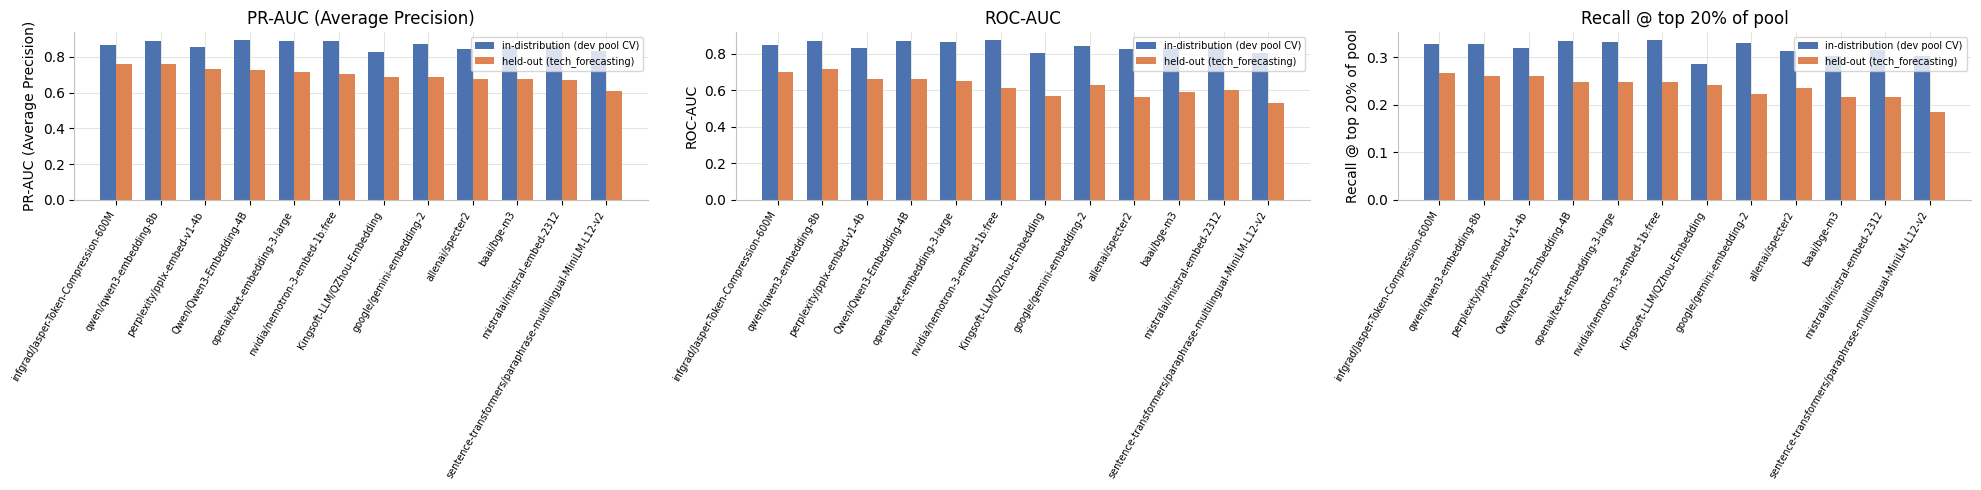

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
x = np.arange(len(summary_df))
width = 0.35
panels = [("pr_auc", "PR-AUC (Average Precision)"), ("roc_auc", "ROC-AUC"), ("recall@20%", "Recall @ top 20% of pool")]

for ax, (metric, title) in zip(axes, panels):
    ax.bar(x - width / 2, summary_df[f"dev_{metric}"], width, label="in-distribution (dev pool CV)", color="#4c72b0")
    ax.bar(x + width / 2, summary_df[f"holdout_{metric}"], width, label="held-out (tech_forecasting)", color="#dd8452")
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df["model"], rotation=60, ha="right", fontsize=7)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## G. Ensemble of embeddings -- does combining sources beat the best single one?

In [13]:
TOP_N = 3
top_models = summary_df.nlargest(TOP_N, "holdout_pr_auc")["model"].tolist()
print(f"Top {TOP_N} by held-out PR-AUC: {top_models}")


def eval_combo(model_names, method):
    vecs = [paper_vectors_by_model[m] for m in model_names]
    if method == "concat":
        V = np.hstack(vecs)
    else:  # mean of L2-normalized vectors -- only valid if every model shares one dim
        if len({v.shape[1] for v in vecs}) > 1:
            return None
        normed = [v / np.linalg.norm(v, axis=1, keepdims=True) for v in vecs]
        V = np.mean(normed, axis=0)

    X_dev, X_holdout = V[:n_dev], V[n_dev:]
    oof_proba = oof_predict(X_dev, y_dev, FOLDS)
    dev_metrics = metric_bundle(y_dev, oof_proba, dev_use_case_keys)
    clf_full = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_dev, y_dev)
    holdout_proba = clf_full.predict_proba(X_holdout)[:, list(clf_full.classes_).index(1)]
    holdout_metrics = metric_bundle(y_holdout, holdout_proba, holdout_use_case_keys)
    return {"dev_pr_auc": dev_metrics["pr_auc"], "holdout_pr_auc": holdout_metrics["pr_auc"],
            "dev_roc_auc": dev_metrics["roc_auc"], "holdout_roc_auc": holdout_metrics["roc_auc"]}


combo_rows = []
for r in range(2, TOP_N + 1):
    for combo in combinations(top_models, r):
        res = eval_combo(list(combo), "concat")
        combo_rows.append({"combo": " + ".join(combo), "method": "concat", **res})
        res_mean = eval_combo(list(combo), "mean_normalized")
        if res_mean is not None:
            combo_rows.append({"combo": " + ".join(combo), "method": "mean_normalized", **res_mean})

combo_df = pd.DataFrame(combo_rows)
print(combo_df.round(4).to_string(index=False))

best_single = summary_df["holdout_pr_auc"].max()
best_combo = combo_df["holdout_pr_auc"].max() if len(combo_df) else float("nan")
print(f"\nBest single-model held-out PR-AUC: {best_single:.4f}")
print(f"Best combo held-out PR-AUC:        {best_combo:.4f}")

Top 3 by held-out PR-AUC: ['infgrad/Jasper-Token-Compression-600M', 'qwen/qwen3-embedding-8b', 'perplexity/pplx-embed-v1-4b']


                                                                                        combo method  dev_pr_auc  holdout_pr_auc  dev_roc_auc  holdout_roc_auc
                              infgrad/Jasper-Token-Compression-600M + qwen/qwen3-embedding-8b concat      0.8948          0.7787       0.8768           0.7355
                          infgrad/Jasper-Token-Compression-600M + perplexity/pplx-embed-v1-4b concat      0.8547          0.7329       0.8317           0.6633
                                        qwen/qwen3-embedding-8b + perplexity/pplx-embed-v1-4b concat      0.8555          0.7343       0.8326           0.6634
infgrad/Jasper-Token-Compression-600M + qwen/qwen3-embedding-8b + perplexity/pplx-embed-v1-4b concat      0.8558          0.7350       0.8329           0.6634

Best single-model held-out PR-AUC: 0.7614
Best combo held-out PR-AUC:        0.7787


## Findings

In [14]:
baseline_row = summary_df[summary_df["model"] == LOCAL_MODEL].iloc[0]
best_dev_model = summary_df.loc[summary_df["dev_pr_auc"].idxmax(), "model"]
best_holdout_model = summary_df.loc[summary_df["holdout_pr_auc"].idxmax(), "model"]

print(f"Best in-distribution (dev pool) by PR-AUC: {best_dev_model}")
print(f"Best held-out (tech_forecasting) by PR-AUC: {best_holdout_model}")
print(f"Local baseline ({LOCAL_MODEL}) -- dev PR-AUC: {baseline_row['dev_pr_auc']:.4f}, "
      f"holdout PR-AUC: {baseline_row['holdout_pr_auc']:.4f}")

beats_both = summary_df[
    (summary_df["dev_pr_auc"] > baseline_row["dev_pr_auc"])
    & (summary_df["holdout_pr_auc"] > baseline_row["holdout_pr_auc"])
    & (summary_df["model"] != LOCAL_MODEL)
]
print("\nModels beating the local baseline on BOTH in-distribution AND held-out PR-AUC")
print("(the bar that matters -- winning in-distribution alone isn't enough, see wf_ensemble_report.md):")
print(beats_both[["model", "dev_pr_auc", "holdout_pr_auc"]].to_string(index=False) if len(beats_both) else "  none")

if FAILED_MODELS:
    print(f"\nNot evaluated (smoke test failed): {FAILED_MODELS}")

Best in-distribution (dev pool) by PR-AUC: Qwen/Qwen3-Embedding-4B
Best held-out (tech_forecasting) by PR-AUC: infgrad/Jasper-Token-Compression-600M
Local baseline (sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2) -- dev PR-AUC: 0.8329, holdout PR-AUC: 0.6076

Models beating the local baseline on BOTH in-distribution AND held-out PR-AUC
(the bar that matters -- winning in-distribution alone isn't enough, see wf_ensemble_report.md):
                                model  dev_pr_auc  holdout_pr_auc
infgrad/Jasper-Token-Compression-600M    0.867047        0.761424
              qwen/qwen3-embedding-8b    0.891086        0.758383
          perplexity/pplx-embed-v1-4b    0.854215        0.729880
              Qwen/Qwen3-Embedding-4B    0.892180        0.723567
        openai/text-embedding-3-large    0.885694        0.715942
      nvidia/nemotron-3-embed-1b:free    0.890515        0.704964
            google/gemini-embedding-2    0.870206        0.686160
                     all